## Importing Relevant Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [34]:
df = pd.read_csv('AusApparalSales4thQrt2020.csv')

In [35]:
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [36]:
df.describe()


,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [38]:
df.shape

(7560, 6)

#### 1.	Data wrangling

In [39]:
# No null values
df.isnull().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [40]:
df.notna().sum()

Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64

In [10]:
#Scaling
#Date, time, state, group are all categorical columns so we can't do a scaling on them but we can do scaling on units and sales
numeric_cols = ['Unit','Sales']
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
# Create a copy for normalized data
df_scaled = df.copy()

# Apply Min-Max scaling
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df_scaled


,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,0.015873,0.015873
...,...,...,...,...,...,...
7555,30-Dec-2020,Afternoon,TAS,Seniors,0.190476,0.190476
7556,30-Dec-2020,Evening,TAS,Kids,0.206349,0.206349
7557,30-Dec-2020,Evening,TAS,Men,0.206349,0.206349
7558,30-Dec-2020,Evening,TAS,Women,0.142857,0.142857


#### 2.	Data analysis

In [41]:
#2a


# Ensure Date is datetime 
df["Date"] = pd.to_datetime(df["Date"])

# Descriptive statistics for Sales
sales_mean = df["Sales"].mean()
sales_median = df["Sales"].median()
sales_mode = df["Sales"].mode()[0]   # mode() can return multiple, pick first
sales_std = df["Sales"].std()

# Descriptive statistics for Units
units_mean = df["Unit"].mean()
units_median = df["Unit"].median()
units_mode = df["Unit"].mode()[0]
units_std = df["Unit"].std()

print("=== Sales Stats ===")
print(f"Mean: {sales_mean:.2f}, Median: {sales_median:.2f}, Mode: {sales_mode}, Std Dev: {sales_std:.2f}")

print("\n=== Units Stats ===")
print(f"Mean: {units_mean:.2f}, Median: {units_median:.2f}, Mode: {units_mode}, Std Dev: {units_std:.2f}")


=== Sales Stats ===
Mean: 45013.56, Median: 35000.00, Mode: 22500, Std Dev: 32253.51

=== Units Stats ===
Mean: 18.01, Median: 14.00, Mode: 9, Std Dev: 12.90


In [42]:
#2b
# Total sales by group
group_sales = df.groupby("Group")["Sales"].sum().sort_values(ascending=False)

highest_group = group_sales.idxmax()
lowest_group = group_sales.idxmin()

print("\n=== Group Sales Totals ===")
print(group_sales)

print(f"\nHighest sales group: {highest_group}")
print(f"Lowest sales group: {lowest_group}")



=== Group Sales Totals ===
Group
Men        85750000
Women      85442500
Kids       85072500
Seniors    84037500
Name: Sales, dtype: int64

Highest sales group:  Men
Lowest sales group:  Seniors


In [14]:

# Total sales by state
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)

highest_state = state_sales.idxmax()
lowest_state = state_sales.idxmin()

print("\n=== State Sales Totals ===")
print(state_sales)

print(f"\nHighest sales state: {highest_state}")
print(f"Lowest sales state: {lowest_state}")



=== State Sales Totals ===
State
VIC    105565000
NSW     74970000
SA      58857500
QLD     33417500
TAS     22760000
NT      22580000
WA      22152500
Name: Sales, dtype: int64

Highest sales state:  VIC
Lowest sales state:  WA


In [15]:
#2d
# Set Date as index for resampling
df_new = df.set_index("Date")

# Weekly sales
weekly_sales = df_new["Sales"].resample("W").sum()

# Monthly sales
monthly_sales = df_new["Sales"].resample("M").sum()

# Quarterly sales
quarterly_sales = df_new["Sales"].resample("Q").sum()

print("\n=== Weekly Sales ===")
print(weekly_sales)

print("\n=== Monthly Sales ===")
print(monthly_sales)

print("\n=== Quarterly Sales ===")
print(quarterly_sales)



=== Weekly Sales ===
Date
2020-10-04    15045000
2020-10-11    27002500
2020-10-18    26640000
2020-10-25    26815000
2020-11-01    21807500
2020-11-08    20865000
2020-11-15    21172500
2020-11-22    21112500
2020-11-29    21477500
2020-12-06    29622500
2020-12-13    31525000
2020-12-20    31655000
2020-12-27    31770000
2021-01-03    13792500
Freq: W-SUN, Name: Sales, dtype: int64

=== Monthly Sales ===
Date
2020-10-31    114290000
2020-11-30     90682500
2020-12-31    135330000
Freq: ME, Name: Sales, dtype: int64

=== Quarterly Sales ===
Date
2020-12-31    340302500
Freq: QE-DEC, Name: Sales, dtype: int64


#### 3.	Data visualization

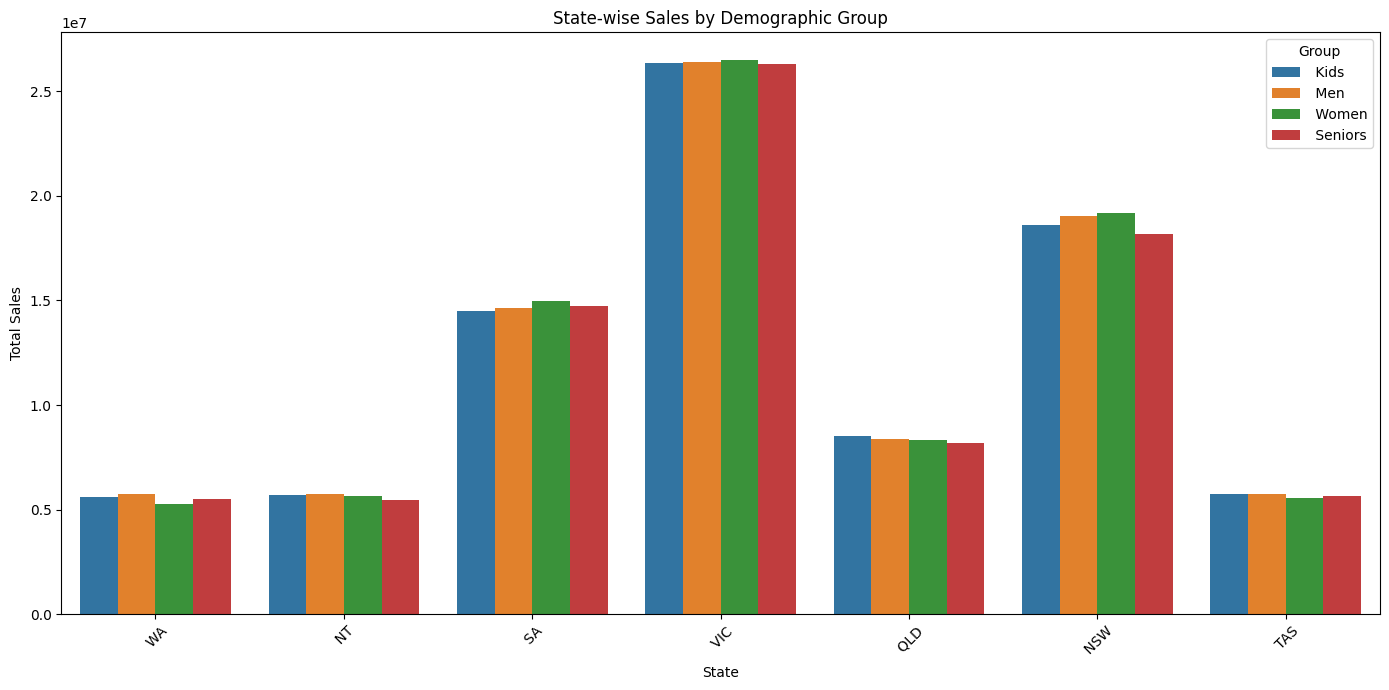

In [43]:
#3 Data Visualization


plt.figure(figsize=(14,7))
sns.barplot(data=df, x="State", y="Sales", hue="Group", estimator=sum, ci=None)
plt.title("State-wise Sales by Demographic Group")
plt.xticks(rotation=45)
plt.ylabel("Total Sales")
plt.xlabel("State")
plt.legend(title="Group")
plt.tight_layout()
plt.show()


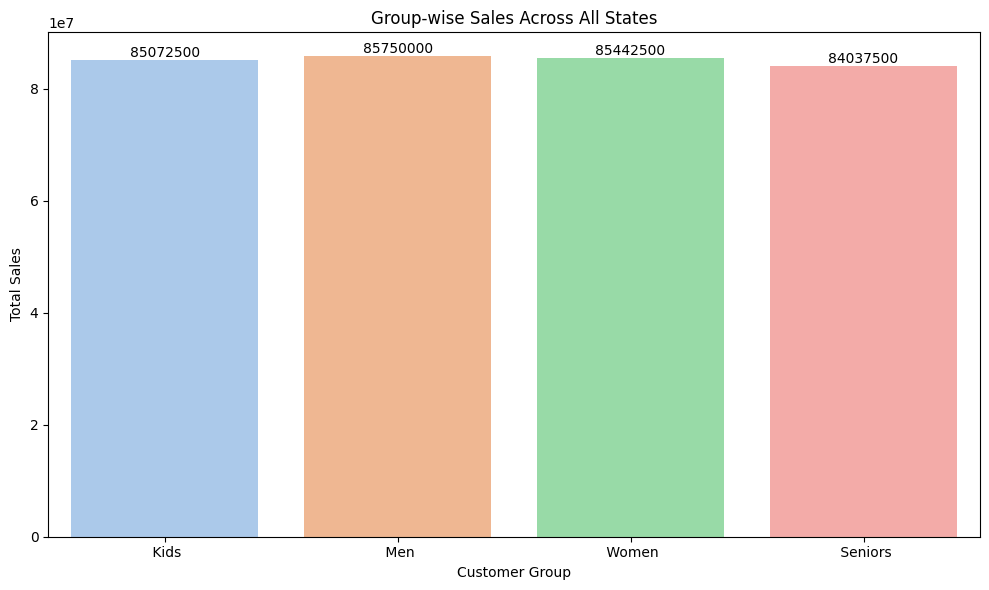

In [44]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=df, x="Group", y="Sales", estimator=sum, ci=None, palette="pastel")

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", label_type="edge", fontsize=10)

plt.title("Group-wise Sales Across All States")
plt.ylabel("Total Sales")
plt.xlabel("Customer Group")
plt.tight_layout()
plt.show()



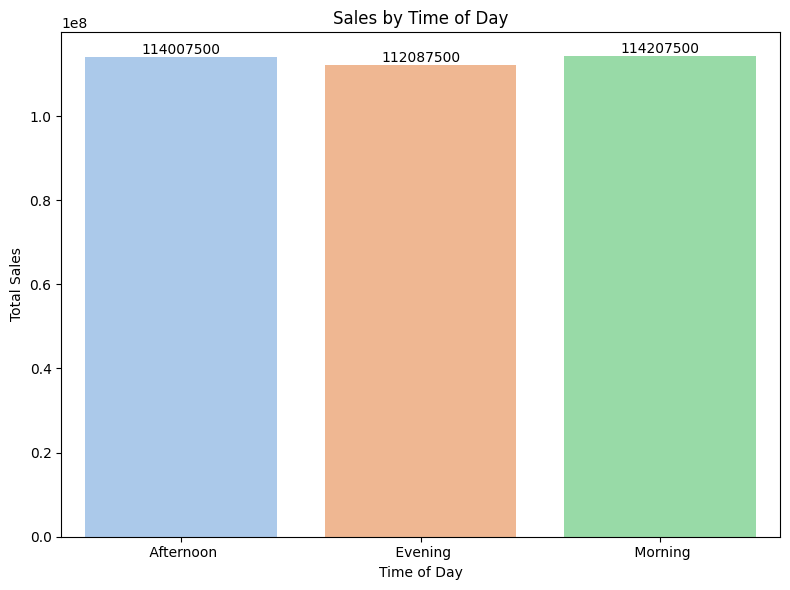

In [45]:

# Aggregate sales by Time of Day
time_sales = df.groupby("Time")["Sales"].sum().reset_index()


# Plot bar chart
plt.figure(figsize=(8,6))
ax = sns.barplot(data=time_sales, x="Time", y="Sales", palette="pastel")

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", label_type="edge", fontsize=10)

plt.title("Sales by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()



In [46]:
#I recommend using Seaborn for visualization because it is optimized for statistical analysis, 
# integrates seamlessly with Pandas, and produces clear, professional plots with minimal code.
#  It allows easy creation of state-wise, group-wise, and time-based comparisons, while Matplotlib 
# is used alongside for value annotations. This combination ensures the dashboard is both insightful and executive-friendly.